# A/B Test Analysis — E-Commerce Landing Page

## Business Context
An e-commerce company ran an A/B test on their landing page.
- **Control Group (A):** Saw the old landing page
- **Treatment Group (B):** Saw the new landing page

**Goal:** Determine if the new page leads to a statistically significant increase in conversions and whether it should be rolled out to all users.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv(r"C:\Users\Shivalika\OneDrive\Desktop\Data Analyst Portfolio Projects\AB_testanalysis_Project\data\ab_data.csv")
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [3]:
df.shape

(294478, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [5]:
df.describe()

,user_id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


In [8]:
df.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['group'].unique()

array(['control', 'treatment'], dtype=object)

In [11]:
print(df['group'].value_counts())
print("\n")
print(df['group'].value_counts(normalize=True) * 100)

group
treatment    147276
control      147202
Name: count, dtype: int64


group
treatment    50.012565
control      49.987435
Name: proportion, dtype: float64


In [12]:
conversion = df.groupby('group')['converted'].mean() * 100
print(conversion)

group
control      12.039918
treatment    11.891958
Name: converted, dtype: float64


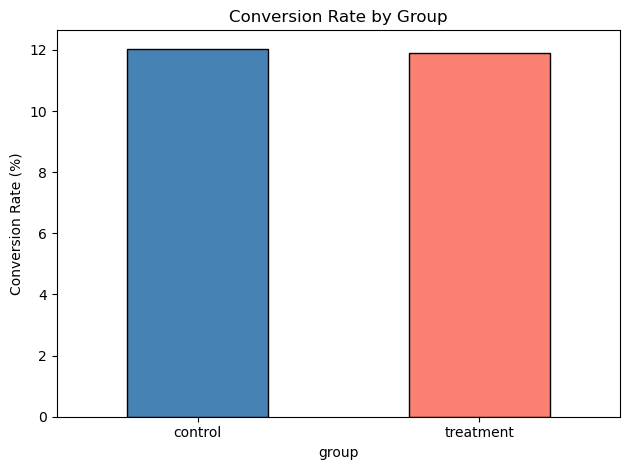

In [14]:
conversion.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Conversion Rate by Group')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('conversion_rate.png', dpi=150, bbox_inches='tight')
plt.show()

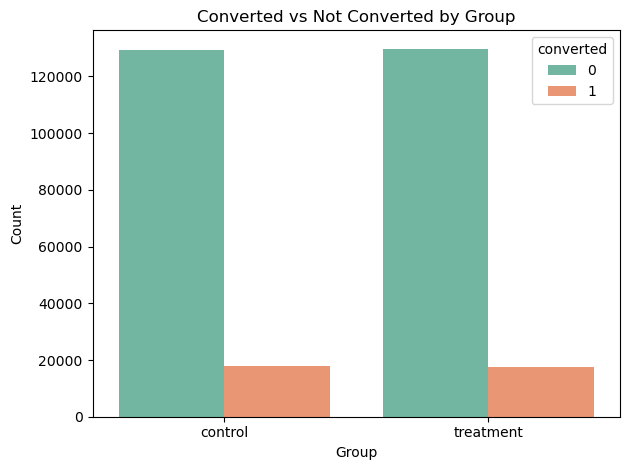

In [15]:
sns.countplot(data=df, x='group', hue='converted', palette='Set2')
plt.title('Converted vs Not Converted by Group')
plt.xlabel('Group')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('converted_count.png', dpi=150, bbox_inches='tight')
plt.show()

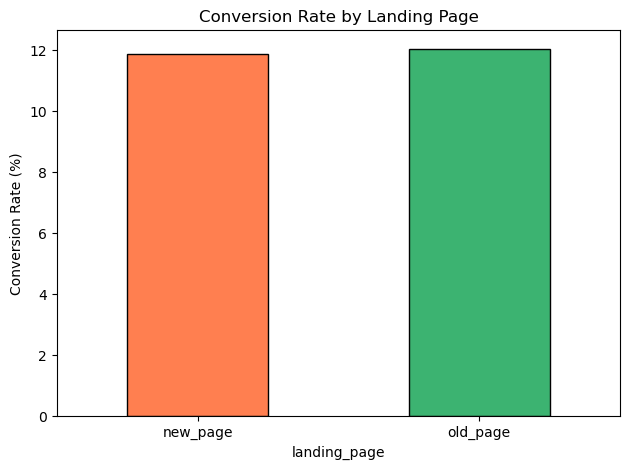

In [16]:
page_conversion = df.groupby('landing_page')['converted'].mean() * 100
page_conversion.plot(kind='bar', color=['coral', 'mediumseagreen'], edgecolor='black')
plt.title('Conversion Rate by Landing Page')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('page_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

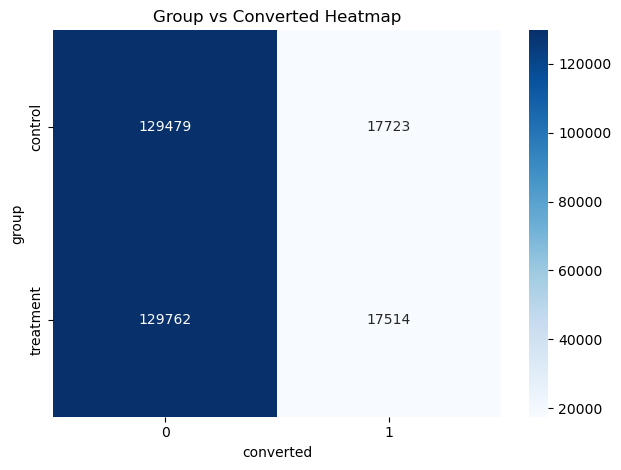

In [17]:
pivot = df.pivot_table(index='group', columns='converted', aggfunc='size')
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues')
plt.title('Group vs Converted Heatmap')
plt.tight_layout()
plt.savefig('group_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Hypothesis

**H₀ (Null):** The new landing page has no effect on conversion rate.
**H₁ (Alternative):** The new landing page increases the conversion rate.

Significance level: α = 0.05

In [20]:
#Confounder check (weekend vs weekday)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

weekend_conversion = df.groupby(['is_weekend', 'group'])['converted'].mean() * 100
print(weekend_conversion)

is_weekend  group    
0           control      11.977007
            treatment    11.952094
1           control      12.206294
            treatment    11.731955
Name: converted, dtype: float64


In [21]:
#Chi-square test
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['group'], df['converted'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square: {chi2:.4f}")
print(f"P-value: {p:.4f}")

Chi-square: 1.5160
P-value: 0.2182


In [22]:
#Hypothesis testing (Z testing)
from statsmodels.stats.proportion import proportions_ztest

control = df[df['group'] == 'control']['converted']
treatment = df[df['group'] == 'treatment']['converted']

n_control = len(control)
n_treatment = len(treatment)

conversions = [control.sum(), treatment.sum()]
nobs = [n_control, n_treatment]

z_stat, p_value = proportions_ztest(conversions, nobs)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically SIGNIFICANT — reject null hypothesis")
else:
    print("Result: NOT significant — fail to reject null hypothesis")

Z-statistic: 1.2369
P-value: 0.2161
Result: NOT significant — fail to reject null hypothesis


In [23]:
#Confidence Interval
import numpy as np

control_rate = control.mean()
treatment_rate = treatment.mean()
diff = treatment_rate - control_rate

se = np.sqrt((control_rate * (1 - control_rate) / n_control) + 
             (treatment_rate * (1 - treatment_rate) / n_treatment))

ci_lower = diff - 1.96 * se
ci_upper = diff + 1.96 * se

print(f"Conversion Rate - Control: {control_rate*100:.4f}%")
print(f"Conversion Rate - Treatment: {treatment_rate*100:.4f}%")
print(f"Difference: {diff*100:.4f}%")
print(f"95% Confidence Interval: ({ci_lower*100:.4f}%, {ci_upper*100:.4f}%)")

Conversion Rate - Control: 12.0399%
Conversion Rate - Treatment: 11.8920%
Difference: -0.1480%
95% Confidence Interval: (-0.3824%, 0.0865%)


## Conclusion & Business Recommendation

- **p-value: 0.2161** — result is NOT statistically significant
- **Conversion difference: -0.148%** — treatment page actually performed slightly worse
- **95% CI: (-0.38%, +0.09%)** — interval crosses zero, confirming no real effect

### Recommendation
Do **not** roll out the new landing page. The data shows no evidence that it improves conversions. The company should either redesign the new page or revert to the original.

In [24]:
#Effect size (% lift + Cohen's h)
control_rate = df[df['group'] == 'control']['converted'].mean()
treatment_rate = df[df['group'] == 'treatment']['converted'].mean()

lift = ((treatment_rate - control_rate) / control_rate) * 100
cohens_h = 2 * np.arcsin(np.sqrt(treatment_rate)) - 2 * np.arcsin(np.sqrt(control_rate))

print(f"% Lift: {lift:.4f}%")
print(f"Cohen's h: {cohens_h:.4f}")

% Lift: -1.2289%
Cohen's h: -0.0046


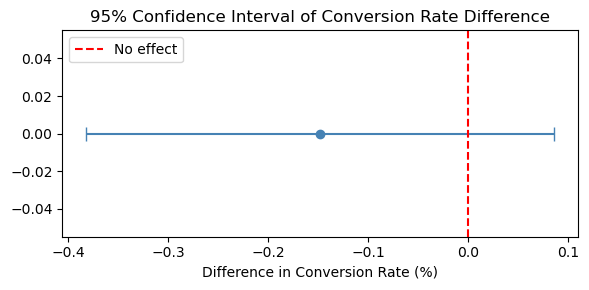

In [25]:
#Confidence Interval plot
ci_mid = (ci_lower + ci_upper) / 2 * 100
ci_err = (ci_upper - ci_lower) / 2 * 100

plt.figure(figsize=(6, 3))
plt.errorbar(x=ci_mid, y=0, xerr=ci_err, fmt='o', color='steelblue', capsize=5)
plt.axvline(x=0, color='red', linestyle='--', label='No effect')
plt.xlabel('Difference in Conversion Rate (%)')
plt.title('95% Confidence Interval of Conversion Rate Difference')
plt.legend()
plt.tight_layout()
plt.savefig('ci_plot.png')
plt.show()

In [26]:
#Power analysis
from statsmodels.stats.power import NormalIndPower

effect_size = abs(cohens_h)
power_analysis = NormalIndPower()
power = power_analysis.solve_power(effect_size=effect_size, nobs1=n_control, alpha=0.05, alternative='two-sided')

print(f"Statistical Power: {power:.4f}")

Statistical Power: 0.2355
